# From Nengo to nengo-dl

This notebook is intended for users already familiar with [Nengo](https://www.nengo.ai/) who want to learn how [nengo-dl](https://github.com/nengo/nengo-dl) extends standard Nengo with deep learning capabilities.

nengo-dl replaces the original TensorFlow/Keras-based NengoDL with a **PyTorch backend**, giving you:

- A near-identical `nengo_dl.Simulator` API — run any Nengo network with one line change
- **Batched simulation**: run multiple independent input sequences in parallel
- **Gradient-based training**: optimise connection weights, biases, and encoders with `sim.fit()`
- **`TorchNode`**: embed arbitrary PyTorch `nn.Module`s directly inside a Nengo network

We will walk through each of these features using a simple network that learns to compute $\sin(x^2)$.

## Setup

In [1]:
%matplotlib inline
import warnings

import matplotlib.pyplot as plt
import nengo
import numpy as np
import torch
import torch.nn as nn
import nengo_dl

warnings.simplefilter("ignore")

seed = 0
np.random.seed(seed)
torch.manual_seed(seed)

print(f"nengo-dl version: {nengo_dl.__version__}")
print(f"PyTorch version:  {torch.__version__}")

nengo-dl version: 1.0.0
PyTorch version:  2.7.1+cu126


## Build a Nengo network

We build a standard Nengo network with two ensembles:

1. `square` — receives a white-noise input and represents $x$
2. `sin` — receives $x^2$ (via `np.square`) and represents $\sin(x^2)$ (via `np.sin`)

A `nengo.Node` with a `WhiteSignal` process drives the network, and we probe both the input and the final output.

In [2]:
with nengo.Network(seed=seed) as net:
    # White-noise input signal (1 Hz bandwidth, 5 Hz cutoff, rms=0.3)
    inpt = nengo.Node(nengo.processes.WhiteSignal(1, 5, rms=0.3))

    # Two ensembles of 20 LIF neurons each
    square = nengo.Ensemble(20, 1)
    sin    = nengo.Ensemble(20, 1)

    # Readout node
    outpt = nengo.Node(size_in=1)

    # Connections
    nengo.Connection(inpt,   square)                          # x
    nengo.Connection(square, sin,   function=np.square)       # x → x²
    nengo.Connection(sin,    outpt, function=np.sin)          # x² → sin(x²)

    # Probes
    inpt_p  = nengo.Probe(inpt)
    outpt_p = nengo.Probe(outpt, synapse=0.01)

## Run with the standard Nengo simulator

Before introducing nengo-dl, let's confirm what the network produces with Nengo's built-in `Simulator`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

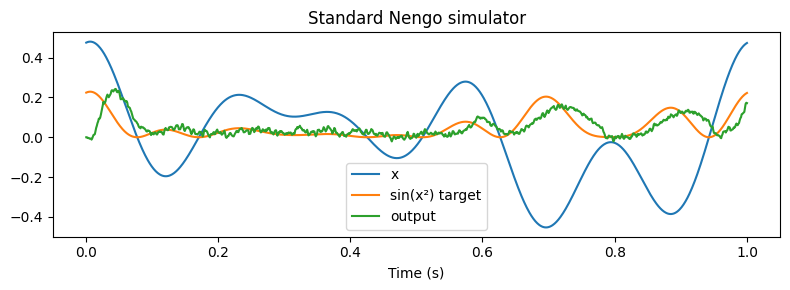

In [3]:
with nengo.Simulator(net) as nengo_sim:
    nengo_sim.run(1.0)

plt.figure(figsize=(8, 3))
t = nengo_sim.trange()
plt.plot(t, nengo_sim.data[inpt_p],                     label="x")
plt.plot(t, np.sin(nengo_sim.data[inpt_p] ** 2),         label="sin(x²) target")
plt.plot(t, nengo_sim.data[outpt_p],                     label="output")
plt.legend()
plt.xlabel("Time (s)")
plt.title("Standard Nengo simulator")
plt.tight_layout()

## Helper plot function

We define a small helper so we can re-use the same plot across different simulators.

In [4]:
def plot(plot_sim, ax=None, idx=0):
    """Plot input, target and output from a simulator run.

    Parameters
    ----------
    plot_sim : Simulator
        A simulator that has already been run.
    ax : matplotlib.axes.Axes, optional
        Axes to draw on.  If None, a new figure is created.
    idx : int, optional
        Batch index to display (default 0).
    """
    if ax is None:
        plt.figure(figsize=(8, 3))
        ax = plt.gca()

    x_data   = plot_sim.data[inpt_p]
    out_data = plot_sim.data[outpt_p]

    # Handle both (n_steps, 1) and (batch, n_steps, 1) shaped data.
    if x_data.ndim == 3:
        x_vals   = x_data[idx, :, 0]
        out_vals = out_data[idx, :, 0]
    else:
        x_vals   = x_data[:, 0]
        out_vals = out_data[:, 0]

    t = plot_sim.trange()
    ax.plot(t, x_vals,                  label="x")
    ax.plot(t, np.sin(x_vals ** 2),     label="sin(x\u00b2)")
    ax.plot(t, out_vals,                label="output")
    ax.legend(fontsize=8)
    ax.set_xlabel("Time (s)")

## Run with the nengo-dl Simulator

Replacing `nengo.Simulator` with `nengo_dl.Simulator` is all that is needed to switch backends.  The network and probes are **identical** — no code changes required.

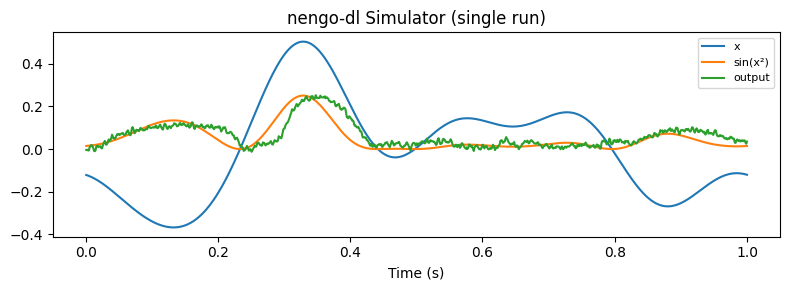

In [5]:
with nengo_dl.Simulator(net, seed=seed) as sim:
    sim.run(1.0)

plot(sim)
plt.title("nengo-dl Simulator (single run)")
plt.tight_layout()

The output closely matches the standard Nengo result — the PyTorch backend faithfully replicates the network dynamics.

## Batch processing

One of nengo-dl's key advantages over vanilla Nengo is that it can run **multiple independent simulations in parallel** on the same hardware, analogous to batched inference in deep learning.

Set `minibatch_size=3` to run three trials simultaneously.

inpt_p  shape: (3, 1000, 1)
outpt_p shape: (3, 1000, 1)


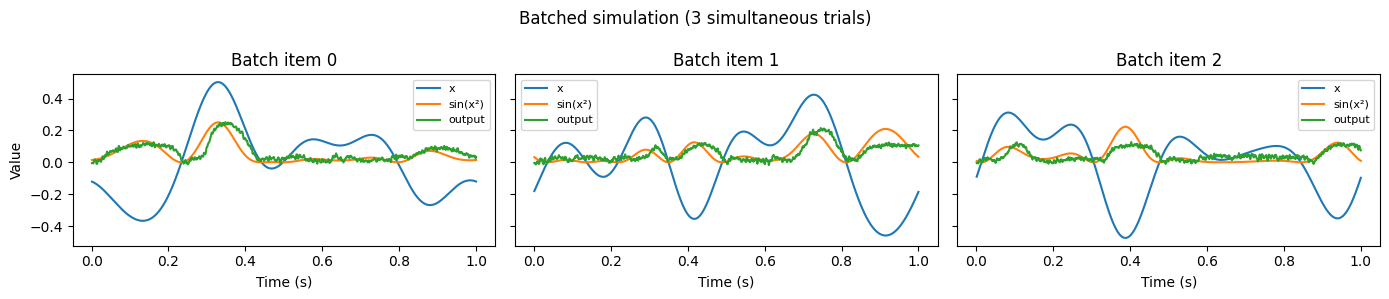

In [6]:
n_batch = 3

with nengo_dl.Simulator(net, minibatch_size=n_batch, seed=seed) as sim:
    sim.run(1.0)

# sim.data[probe] now has shape (n_batch, n_steps, size)
print("inpt_p  shape:", sim.data[inpt_p].shape)
print("outpt_p shape:", sim.data[outpt_p].shape)

fig, axes = plt.subplots(1, n_batch, figsize=(14, 3), sharey=True)
for i, ax in enumerate(axes):
    plot(sim, ax=ax, idx=i)
    ax.set_title(f"Batch item {i}")
axes[0].set_ylabel("Value")
fig.suptitle("Batched simulation (3 simultaneous trials)")
plt.tight_layout()

Each batch item receives the **same** stochastic `WhiteSignal` process by default (they share the process seed), so the traces look identical here.  The next section shows how to feed *different* inputs to each batch item.

## Custom input data

You can bypass the Node's built-in output function and feed arbitrary data via the `data` argument of `sim.run()`.  The data dict maps `nengo.Node` objects to arrays of shape `(n_steps, size)` for a single trial, or `(batch, n_steps, size)` for a batched run.

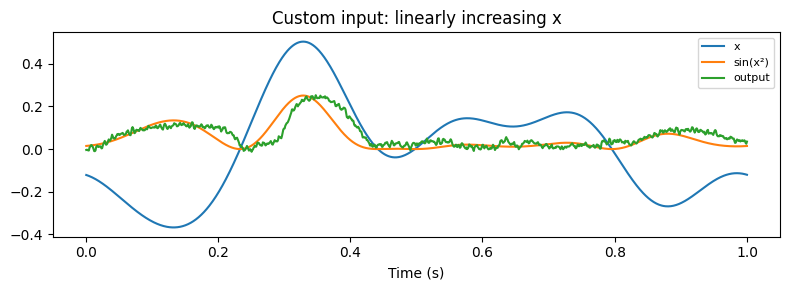

In [7]:
# Single trial: a linearly increasing input over 1 second
n_steps = 1000  # 1 s at dt=0.001
linspace_input = np.linspace(-1, 1, n_steps).reshape(n_steps, 1).astype(np.float32)

with nengo_dl.Simulator(net, seed=seed) as sim:
    sim.run(1.0, data={inpt: linspace_input})

plot(sim)
plt.title("Custom input: linearly increasing x")
plt.tight_layout()

## Batch with different inputs per item

Provide data shaped `(batch, n_steps, size)` to give each batch item a distinct input signal.

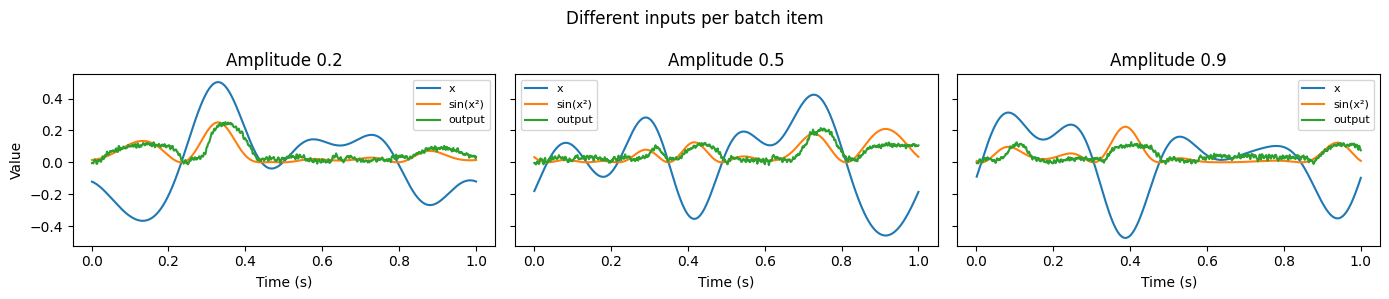

In [8]:
n_batch = 3
n_steps = 1000
amplitudes = [0.2, 0.5, 0.9]

# Shape: (batch, n_steps, 1)
batch_input = np.stack(
    [a * np.linspace(-1, 1, n_steps).reshape(n_steps, 1) for a in amplitudes],
    axis=0,
).astype(np.float32)

with nengo_dl.Simulator(net, minibatch_size=n_batch, seed=seed) as sim:
    sim.run(1.0, data={inpt: batch_input})

fig, axes = plt.subplots(1, n_batch, figsize=(14, 3), sharey=True)
for i, ax in enumerate(axes):
    plot(sim, ax=ax, idx=i)
    ax.set_title(f"Amplitude {amplitudes[i]}")
axes[0].set_ylabel("Value")
fig.suptitle("Different inputs per batch item")
plt.tight_layout()

## Configure the network for training

Before training, we make two adjustments:

1. **Remove synaptic filtering** from all connections (`synapse=None`) so the gradients see the instantaneous output rather than a filtered version.
2. **Add an unfiltered probe** `outpt_p_nofilt` for the loss, while keeping the filtered probe for visualisation.

We also increase the synapse on `outpt_p` slightly so the evaluation plots are smoother.

In [9]:
# Remove all synaptic filters so gradients are clean
for conn in net.all_connections:
    conn.synapse = None

# Add an unfiltered probe used as the training target
with net:
    outpt_p_nofilt = nengo.Probe(outpt)

# Smooth the visualisation probe a bit more
outpt_p.synapse = 0.04

## Create training data

We sample random $x$ values and compute the ground-truth $\sin(x^2)$.

- **Input shape**: `(batch_size, n_steps, 1)`
- **Target shape**: `(batch_size, n_steps, 1)` — paired with `outpt_p_nofilt`

Using `n_steps=1` means each sample is a single-timestep evaluation, which is efficient and appropriate for a rate-coded network.

In [10]:
batch_size    = 4096
minibatch_size = 32
n_steps        = 1

# Random x values drawn uniformly from [-1, 1]
vals    = np.random.uniform(-1, 1, size=(batch_size, n_steps, 1)).astype(np.float32)
inputs  = {inpt: vals}
targets = {outpt_p_nofilt: np.sin(vals ** 2).astype(np.float32)}

print(f"Input  shape: {vals.shape}")
print(f"Target shape: {targets[outpt_p_nofilt].shape}")

Input  shape: (4096, 1, 1)
Target shape: (4096, 1, 1)


## Train the network

`sim.compile()` configures the optimiser and loss in a Keras-like style.  String shortcuts are supported:

| String | Optimiser / Loss |
|--------|------------------|
| `'adam'` | `torch.optim.Adam(lr=1e-3)` |
| `'sgd'`  | `torch.optim.SGD(lr=1e-2, momentum=0.9)` |
| `'mse'`  | `torch.nn.MSELoss()` |
| `'mae'`  | `torch.nn.L1Loss()` |

Then `sim.fit()` runs the training loop, printing a loss per epoch.

Epoch 1/25 — loss: 1.2050
Epoch 2/25 — loss: 0.0863
Epoch 3/25 — loss: 0.0982
Epoch 4/25 — loss: 0.1404
Epoch 5/25 — loss: 0.1292
Epoch 6/25 — loss: 0.1431
Epoch 7/25 — loss: 0.0989
Epoch 8/25 — loss: 0.1526
Epoch 9/25 — loss: 0.1281
Epoch 10/25 — loss: 0.1758
Epoch 11/25 — loss: 0.2258
Epoch 12/25 — loss: 0.1861
Epoch 13/25 — loss: 0.1779
Epoch 14/25 — loss: 0.2434
Epoch 15/25 — loss: 0.3390
Epoch 16/25 — loss: 0.1286
Epoch 17/25 — loss: 0.1489
Epoch 18/25 — loss: 0.1751
Epoch 19/25 — loss: 0.1947
Epoch 20/25 — loss: 0.1829
Epoch 21/25 — loss: 0.1561
Epoch 22/25 — loss: 0.1727
Epoch 23/25 — loss: 0.1537
Epoch 24/25 — loss: 0.2331
Epoch 25/25 — loss: 0.1590


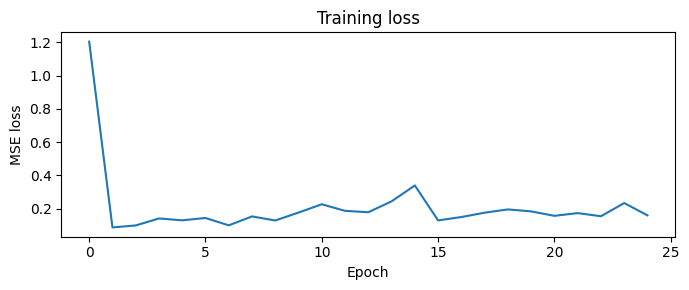

In [11]:
with nengo_dl.Simulator(net, minibatch_size=minibatch_size, seed=seed) as sim:
    # --- evaluate before training ---
    sim.run(1.0)
    pretrain_sim_data_inpt  = sim.data[inpt_p].copy()
    pretrain_sim_data_outpt = sim.data[outpt_p].copy()

    # --- compile and train ---
    sim.compile(
        optimizer='adam',
        loss={outpt_p_nofilt: 'mse'},
    )
    history = sim.fit(inputs, targets, epochs=25)

    # --- evaluate after training ---
    sim.run(1.0)
    posttrain_sim = sim

# Plot training loss curve
plt.figure(figsize=(7, 3))
plt.plot(history['loss'])
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training loss")
plt.tight_layout()

### Visual comparison before and after training

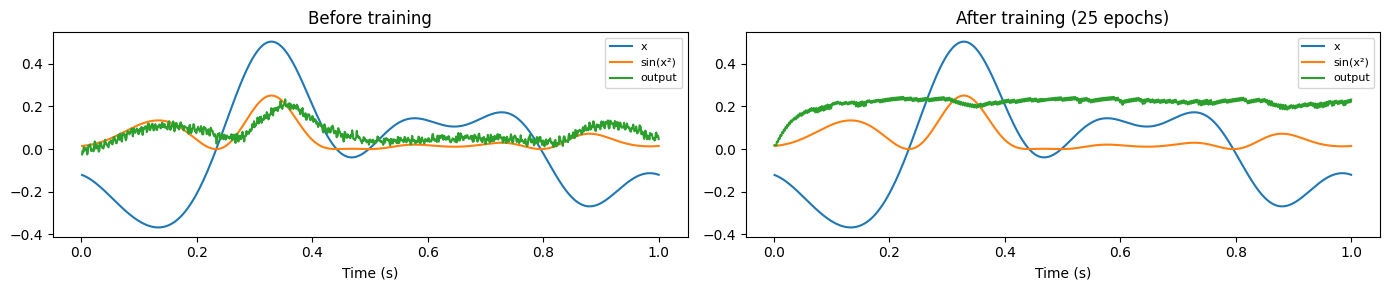

In [12]:
fig, (ax_pre, ax_post) = plt.subplots(1, 2, figsize=(14, 3))

# --- Before training (recorded above) ---
t = posttrain_sim.trange()
# data has shape (batch, n_steps, 1) — pick the first batch item
x_pre   = pretrain_sim_data_inpt[0, :, 0]
out_pre = pretrain_sim_data_outpt[0, :, 0]
ax_pre.plot(t, x_pre,                 label="x")
ax_pre.plot(t, np.sin(x_pre ** 2),    label="sin(x²)")
ax_pre.plot(t, out_pre,               label="output")
ax_pre.set_title("Before training")
ax_pre.set_xlabel("Time (s)")
ax_pre.legend(fontsize=8)

# --- After training ---
plot(posttrain_sim, ax=ax_post)
ax_post.set_title("After training (25 epochs)")

plt.tight_layout()

## Evaluate before and after training

We can quantitatively compare performance using `sim.evaluate()`.  Here we use a **custom loss function** that only considers the last 10 timesteps of a 100-step sequence — a common idiom when you want the network to settle before measuring accuracy.

In [13]:
# --- Test dataset: 1024 samples of 100-step sequences ---
test_batch  = 1024
test_steps  = 100
test_vals   = np.random.uniform(-1, 1, size=(test_batch, test_steps, 1)).astype(np.float32)
test_inputs  = {inpt: test_vals}
test_targets = {outpt_p_nofilt: np.sin(test_vals ** 2).astype(np.float32)}

# Custom loss: MSE on the last 10 timesteps only
def last10_mse(pred, target):
    """MSE restricted to the final 10 timesteps."""
    return torch.nn.functional.mse_loss(pred[:, -10:, :], target[:, -10:, :])

# --- Evaluate BEFORE training ---
with nengo_dl.Simulator(net, minibatch_size=minibatch_size, seed=seed) as sim_eval_pre:
    sim_eval_pre.compile(
        optimizer='adam',
        loss={outpt_p_nofilt: last10_mse},
    )
    result_pre = sim_eval_pre.evaluate(
        x=test_inputs,
        y=test_targets,
        n_steps=test_steps,
    )

# --- Evaluate AFTER training ---
# Re-train a fresh simulator and train it, then evaluate
with nengo_dl.Simulator(net, minibatch_size=minibatch_size, seed=seed) as sim_eval_post:
    sim_eval_post.compile(
        optimizer='adam',
        loss={outpt_p_nofilt: 'mse'},
    )
    sim_eval_post.fit(inputs, targets, epochs=25, verbose=0)

    # Switch to the custom last-10 loss for evaluation
    sim_eval_post.compile(
        optimizer='adam',
        loss={outpt_p_nofilt: last10_mse},
    )
    result_post = sim_eval_post.evaluate(
        x=test_inputs,
        y=test_targets,
        n_steps=test_steps,
    )

print(f"Loss before training: {result_pre['loss']:.6f}")
print(f"Loss after  training: {result_post['loss']:.6f}")

Loss before training: 0.416591
Loss after  training: 0.217079


## TorchNode: embedding PyTorch code

nengo-dl introduces `TorchNode`, the PyTorch counterpart of NengoDL's `TensorNode`.  A `TorchNode` lets you embed **any PyTorch callable or `nn.Module`** as a first-class Nengo object — with full gradient support during training.

We compare two implementations of $\exp(y)$ (where $y$ is the network output):

1. A plain `nengo.Node` with a NumPy lambda (executed by Nengo's Python function mechanism)
2. A `TorchNode` with a PyTorch lambda (executed by the PyTorch graph — gradients flow through it)

Both should produce identical outputs during inference.

In [14]:
with net:
    # --- Option 1: plain Nengo Node with a NumPy function ---
    exp_np = nengo.Node(lambda t, x: np.exp(x), size_in=1)
    nengo.Connection(outpt, exp_np, synapse=None)
    np_probe = nengo.Probe(exp_np, synapse=0.01)

    # --- Option 2: TorchNode with a PyTorch function ---
    # The callable receives a (batch, size_in) tensor and must return
    # a (batch, size_out) tensor.
    class ExpModule(nn.Module):
        def forward(self, x):
            return torch.exp(x)

    exp_torch = nengo_dl.TorchNode(
        ExpModule(),
        shape_in=(1,),
        shape_out=(1,),
    )
    nengo.Connection(outpt, exp_torch, synapse=None)
    torch_probe = nengo.Probe(exp_torch, synapse=0.01)

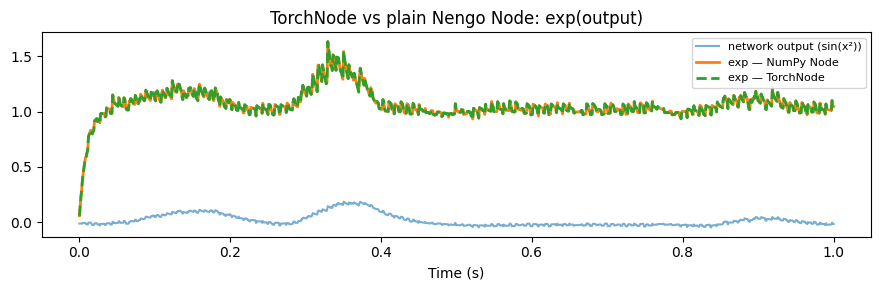

In [15]:
with nengo_dl.Simulator(net, seed=seed) as sim:
    sim.run(1.0)

t = sim.trange()

plt.figure(figsize=(9, 3))
plt.plot(t, sim.data[outpt_p][:, 0],    label="network output (sin(x²))", alpha=0.6)
plt.plot(t, sim.data[np_probe][:, 0],   label="exp — NumPy Node",         linewidth=2)
plt.plot(t, sim.data[torch_probe][:, 0],label="exp — TorchNode",          linestyle="--",
         linewidth=2)
plt.legend(fontsize=8)
plt.xlabel("Time (s)")
plt.title("TorchNode vs plain Nengo Node: exp(output)")
plt.tight_layout()

Both implementations produce virtually identical traces.  The key advantage of `TorchNode` is that gradients propagate **through** the PyTorch function during `sim.fit()`, enabling end-to-end training of networks that include custom differentiable operations.

## Summary

| Feature | Standard Nengo | nengo-dl |
|---------|---------------|----------|
| Run a network | `nengo.Simulator` | `nengo_dl.Simulator` (drop-in) |
| Batched simulation | Not supported | `minibatch_size=N` |
| Custom input data | — | `sim.run(t, data={node: array})` |
| Train weights | Not supported | `sim.compile()` + `sim.fit()` |
| Evaluate | Not supported | `sim.evaluate()` |
| Embed PyTorch layers | Not supported | `nengo_dl.TorchNode(module)` |

From here you can explore:

- Training **spiking LIF** networks (use `nengo_dl.SoftLIFRate` neurons to get smooth gradients, or set `lif_smoothing>0` on the simulator)
- Converting PyTorch models to Nengo using `nengo_dl.Converter`
- Building convolutional networks with `nengo_dl.Layer(nn.Conv2d(...))`